# Grocery Store Simulation Data Engineering Notebook
**Dataset:** 6,668 simulated days Star schema (fact_sales + 5 dimensions)  
**Goal:** Explore the data, validate quality, and extract business insights

## 1. Imports & Load Data

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


customers = pd.read_csv('data/dim_customer_6668.csv',
    header=None,
    names=['id', 'source_id', 'name', 'is_loyalty', 'join_date'])

employee = pd.read_csv('data/dim_employee_6668.csv',
    header=None,
    names=['id', 'source_id', 'name', 'role'])

payment = pd.read_csv('data/dim_payment_method_6668.csv',
    header=None,
    names=['id', 'method'])

product = pd.read_csv('data/dim_product_6668.csv',
    header=None,
    names=['id', 'source_id', 'name', 'category', 'subcategory', 'unit_cost'])

time = pd.read_csv('data/dim_time_6668.csv',
    header=None,
    names=['id', 'simulated_day', 'hour_of_day', 'time_label', 'part_of_day', 'is_rush_hour'])

sales = pd.read_csv('data/fact_sales_6668.csv',
    header=None,
    names=['id', 'dim_time_id', 'dim_product_id', 'dim_customer_id',
           'dim_employee_id', 'dim_payment_method_id', 'source_transaction_id',
           'simulated_day', 'quantity_sold', 'unit_price', 'unit_cost',
           'revenue', 'cost', 'profit'])


tables = [('customers', customers), ('employee', employee),
          ('payment', payment), ('product', product),
          ('time', time), ('sales', sales)]

## 2. Schema Overview
Understand the shape of every table before touching the data.

In [33]:
# Row counts, column counts, and column names for every table
for name, df in tables:
    print(f"{name}: {df.shape[0]:,} rows, {df.shape[1]} cols")
    print(f"  columns: {list(df.columns)}\n")

customers: 133,101 rows, 5 cols
  columns: ['id', 'source_id', 'name', 'is_loyalty', 'join_date']

employee: 40,002 rows, 4 cols
  columns: ['id', 'source_id', 'name', 'role']

payment: 4 rows, 2 cols
  columns: ['id', 'method']

product: 293,348 rows, 6 cols
  columns: ['id', 'source_id', 'name', 'category', 'subcategory', 'unit_cost']

time: 93,338 rows, 6 cols
  columns: ['id', 'simulated_day', 'hour_of_day', 'time_label', 'part_of_day', 'is_rush_hour']

sales: 10,135,454 rows, 14 cols
  columns: ['id', 'dim_time_id', 'dim_product_id', 'dim_customer_id', 'dim_employee_id', 'dim_payment_method_id', 'source_transaction_id', 'simulated_day', 'quantity_sold', 'unit_price', 'unit_cost', 'revenue', 'cost', 'profit']



In [34]:
# Data types for the fact table 
sales.dtypes

id                         int64
dim_time_id                int64
dim_product_id             int64
dim_customer_id            int64
dim_employee_id            int64
dim_payment_method_id      int64
source_transaction_id      int64
simulated_day              int64
quantity_sold              int64
unit_price               float64
unit_cost                float64
revenue                  float64
cost                     float64
profit                   float64
dtype: object

In [35]:
# Small sample from each table 
for name, df in tables:
    n = min(5, len(df))
    print(f"\n {name} ")
    print(df.sample(n))


 customers 
          id  source_id         name is_loyalty  join_date
47590  47604         13   Mia Walker          t        NaN
59690  59704          9  Irene Clark          t        NaN
86501  86528          7    Grace Kim          t        NaN
13163  13164         20  Tina Carter          t        NaN
83769  83796         13   Mia Walker          t        NaN

 employee 
          id  source_id          name     role
10746  10774          1  Maria Santos  Cashier
5753    5754          6    Tom Nguyen  Cashier
37180  37235          6    Tom Nguyen  Cashier
17543  17571          5    Sara Ahmed  Cashier
9752    9780          3    Linda Park  Cashier

 payment 
   id  method
3   4  mobile
1   2  credit
2   3   debit
0   1    cash

 product 
            id  source_id                   name category   subcategory  \
95860    95520         18        Bagels (6 pack)   Bakery        Bagels   
3312      3311         29  Canned Diced Tomatoes   Pantry  Canned Goods   
166222  165560        

## 3. Data Quality Checks
Validate the data

In [36]:
# Missing values across all tables
# Shows % of missing values per column
print("MISSING VALUES (% per column)")
for name, df in tables:
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(2)
    has_nulls = missing_pct[missing_pct > 0]
    if len(has_nulls) > 0:
        print(f"\n{name}:")
        print(has_nulls.to_string())
    else:
        print(f"{name}: no missing values ")

MISSING VALUES (% per column)

customers:
join_date    100.0
employee: no missing values 
payment: no missing values 
product: no missing values 
time: no missing values 
sales: no missing values 


In [37]:
# Duplicate checks 
# IDs should be unique, if duplicates exist something went wrong in the pipeline
print("DUPLICATE ID CHECKS")
for name, df in tables:
    dupes = df['id'].duplicated().sum()
    status = 'None' if dupes == 0 else f'{dupes} duplicates'
    print(f"{name}: {status}")

DUPLICATE ID CHECKS
customers: None
employee: None
payment: None
product: None
time: None
sales: None


In [38]:
# Referential integrity check 
# Every foreign key in fact_sales should exist in its dimension table

print("REFERENTIAL INTEGRITY")

checks = [
    ('dim_product_id',         product,   'Product'),
    ('dim_customer_id',        customers, 'Customer'),
    ('dim_employee_id',        employee,  'Employee'),
    ('dim_payment_method_id',  payment,   'Payment'),
    ('dim_time_id',            time,      'Time'),
]

for fk_col, dim_df, label in checks:
    orphans = ~sales[fk_col].isin(dim_df['id'])
    count = orphans.sum()
    status = 'Good' if count == 0 else f' {count:,} orphaned rows'
    print(f"{label}: {status}")

REFERENTIAL INTEGRITY
Product: Good
Customer: Good
Employee: Good
Payment: Good
Time: Good


In [39]:
# Sanity check on measures
# Revenue should always equal quantity * unit_price, if not, something was calculated wrong in the simulation
sales['revenue_check'] = (sales['quantity_sold'] * sales['unit_price']).round(2)
mismatches = (sales['revenue_check'] - sales['revenue']).abs() > 0.01  # allow 1 cent rounding
print(f"Revenue calculation mismatches: {mismatches.sum():,}")

# Profit should equal revenue - cost
sales['profit_check'] = (sales['revenue'] - sales['cost']).round(2)
profit_mismatches = (sales['profit_check'] - sales['profit']).abs() > 0.01
print(f"Profit calculation mismatches:  {profit_mismatches.sum():,}")

# Clean up temp columns
sales.drop(columns=['revenue_check', 'profit_check'], inplace=True)

Revenue calculation mismatches: 0
Profit calculation mismatches:  0


In [40]:
# Value range checks 
# No negative quantities, prices, or revenues 
print("VALUE RANGE CHECKS")
for col in ['quantity_sold', 'unit_price', 'revenue', 'cost']:
    negatives = (sales[col] < 0).sum()
    status = 'Good' if negatives == 0 else f' {negatives:,} negative values!'
    print(f"{col}: {status}")

print(f"\nDay range: {sales['simulated_day'].min()} to {sales['simulated_day'].max()}")
print(f"Expected:  1 to 6668")

VALUE RANGE CHECKS
quantity_sold: Good
unit_price: Good
revenue: Good
cost: Good

Day range: 1 to 6667
Expected:  1 to 6668


## 4. High Level Business Summary
Top-level numbers for executive dashboard.

In [41]:
# Overall totals
print("OVERALL SUMMARY")
print(f"Total Revenue:      ${sales['revenue'].sum():>15,.2f}")
print(f"Total Cost:         ${sales['cost'].sum():>15,.2f}")
print(f"Total Profit:       ${sales['profit'].sum():>15,.2f}")
print(f"Profit Margin:      {sales['profit'].sum() / sales['revenue'].sum() * 100:>14.1f}%")
print()
print(f"Total Line Items:   {len(sales):>15,}")
print(f"Unique Transactions:{sales['source_transaction_id'].nunique():>15,}")
print(f"Simulated Days:     {sales['simulated_day'].nunique():>15,}")
print()
print(f"Avg Revenue/Day:    ${sales.groupby('simulated_day')['revenue'].sum().mean():>15,.2f}")
print(f"Avg Profit/Day:     ${sales.groupby('simulated_day')['profit'].sum().mean():>15,.2f}")

OVERALL SUMMARY
Total Revenue:      $ 101,686,610.01
Total Cost:         $  50,625,258.25
Total Profit:       $  51,061,351.76
Profit Margin:                50.2%

Total Line Items:        10,135,454
Unique Transactions:      2,253,795
Simulated Days:               6,667

Avg Revenue/Day:    $      15,252.23
Avg Profit/Day:     $       7,658.82


## 5. Product Analysis
Join the fact table to the product dimension to answer product-level questions.

In [42]:
# Join sales to product dimension 
# This is the equivalent of a SQL LEFT JOIN
sales_product = sales.merge(
    product[['id', 'name', 'category', 'subcategory']],
    left_on='dim_product_id',
    right_on='id',
    how='left'
).rename(columns={'name': 'product_name'})

print(f"Rows after join: {len(sales_product):,}  (should match original: {len(sales):,}")

Rows after join: 10,135,454  (should match original: 10,135,454


In [43]:
# Top 10 products by revenue 
top_products = (
    sales_product
    .groupby('product_name')
    .agg(
        total_revenue = ('revenue',       'sum'),
        total_profit  = ('profit',        'sum'),
        units_sold    = ('quantity_sold',  'sum'),
        num_sales     = ('id_x',           'count')
    )
    .sort_values('total_revenue', ascending=False)
    .head(10)
    .reset_index()
)

top_products['profit_margin'] = (top_products['total_profit'] / top_products['total_revenue'] * 100).round(1)
top_products['total_revenue'] = top_products['total_revenue'].map('${:,.2f}'.format)
top_products['total_profit']  = top_products['total_profit'].map('${:,.2f}'.format)
top_products

,product_name,total_revenue,total_profit,units_sold,num_sales,profit_margin
0,Coffee (12oz ground),"$5,165,420.26","$2,407,465.06",574574,229735,46.6
1,Olive Oil (16oz),"$4,601,648.74","$2,182,759.54",575926,229975,47.4
2,Coca-Cola (12pk cans),"$4,598,604.55","$2,008,652.05",575545,229803,43.7
3,Chicken Nuggets (24oz),"$4,318,097.35","$2,127,340.35",576515,230483,49.3
4,Bacon (12oz),"$4,034,516.16","$1,841,216.96",577184,230512,45.6
5,Frozen Pizza (pepperoni),"$4,018,732.74","$2,006,491.74",574926,230026,49.9
6,Greek Yogurt (32oz),"$3,450,455.64","$1,607,140.44",576036,230163,46.6
7,Chicken Breast (lb),"$3,446,909.56","$1,605,488.76",575444,229980,46.6
8,Ground Beef 80/20 (lb),"$3,182,218.11","$1,443,301.11",579639,231697,45.4
9,Butter (1lb),"$3,039,808.57","$1,258,446.27",574633,230228,41.4


In [44]:
# Revenue by category 
category_summary = (
    sales_product
    .groupby('category')
    .agg(
        total_revenue = ('revenue', 'sum'),
        total_profit  = ('profit',  'sum'),
        units_sold    = ('quantity_sold', 'sum')
    )
    .sort_values('total_revenue', ascending=False)
    .reset_index()
)

category_summary['profit_margin'] = (
    category_summary['total_profit'] / category_summary['total_revenue'] * 100
).round(1)

category_summary

,category,total_revenue,total_profit,units_sold,profit_margin
0,Pantry,18610050.39,9996542.24,5761601,53.7
1,Beverages,17534498.02,8494668.02,2880898,48.4
2,Dairy,16657753.27,7329808.47,4031203,44.0
3,Frozen,14364871.14,7340723.74,2879086,51.1
4,Meat,13534600.41,6207540.01,2307609,45.9
5,Produce,10639825.88,5842398.98,4598522,54.9
6,Bakery,10345010.90,5849670.30,2881660,56.5


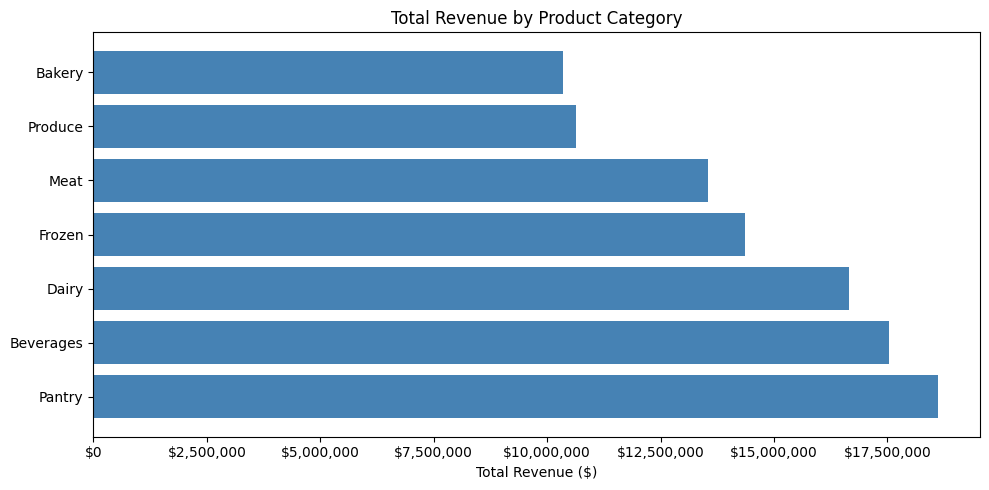

In [45]:
# Chart: revenue by category 
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(category_summary['category'], category_summary['total_revenue'], color='steelblue')
ax.set_xlabel('Total Revenue ($)')
ax.set_title('Total Revenue by Product Category')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

## 6. Time Series Analysis
6,668 days of data is a rich time series. Look at trends, seasonality, and patterns over time.

In [46]:
# Daily revenue aggregation 
# Roll up all line items to one row per simulated day
daily = (
    sales
    .groupby('simulated_day')
    .agg(
        daily_revenue = ('revenue',              'sum'),
        daily_profit  = ('profit',               'sum'),
        daily_cost    = ('cost',                 'sum'),
        num_items     = ('id',                   'count'),
        num_transactions = ('source_transaction_id', 'nunique')
    )
    .reset_index()
)

# Add rolling averages to smooth out daily noise
daily['revenue_30d_avg'] = daily['daily_revenue'].rolling(30).mean()   # 30-day moving average
daily['revenue_90d_avg'] = daily['daily_revenue'].rolling(90).mean()   # 90-day moving average

print(f"Daily revenue range: ${daily['daily_revenue'].min():,.2f} — ${daily['daily_revenue'].max():,.2f}")
print(f"Daily revenue mean:  ${daily['daily_revenue'].mean():,.2f}")
daily.head()

Daily revenue range: $11,590.83 — $18,901.93
Daily revenue mean:  $15,252.23


,simulated_day,daily_revenue,daily_profit,daily_cost,num_items,num_transactions,revenue_30d_avg,revenue_90d_avg
0,1,13920.59,6966.04,6954.55,1401,313,NaN,NaN
1,2,13137.65,6596.35,6541.30,1340,290,NaN,NaN
2,3,16046.75,8059.15,7987.60,1593,348,NaN,NaN
3,4,16389.71,8240.71,8149.00,1663,378,NaN,NaN
4,5,14976.32,7504.77,7471.55,1514,326,NaN,NaN


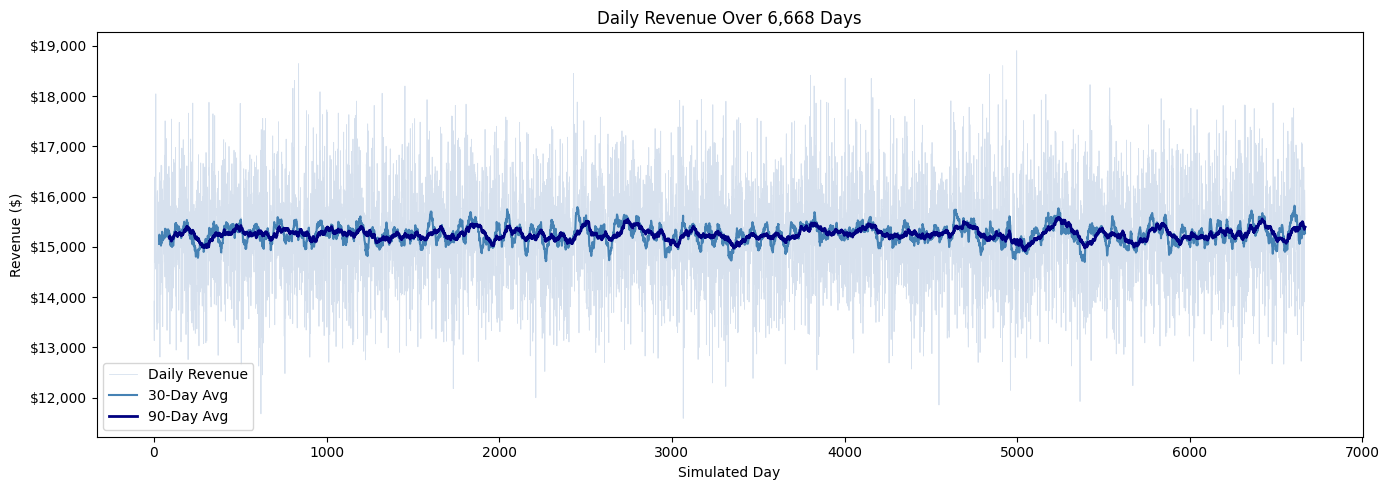

In [47]:
# Chart: daily revenue with rolling averages 
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(daily['simulated_day'], daily['daily_revenue'],
        color='lightsteelblue', alpha=0.5, linewidth=0.6, label='Daily Revenue')
ax.plot(daily['simulated_day'], daily['revenue_30d_avg'],
        color='steelblue', linewidth=1.5, label='30-Day Avg')
ax.plot(daily['simulated_day'], daily['revenue_90d_avg'],
        color='navy', linewidth=2, label='90-Day Avg')

ax.set_xlabel('Simulated Day')
ax.set_ylabel('Revenue ($)')
ax.set_title('Daily Revenue Over 6,668 Days')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

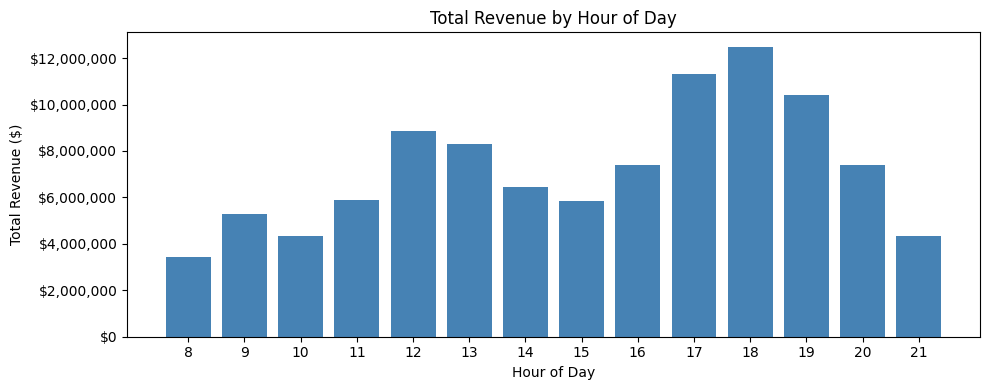

In [48]:
# Revenue by hour of day 
# Join to time dimension to get hour_of_day
sales_time = sales.merge(
    time[['id', 'hour_of_day', 'part_of_day', 'is_rush_hour']],
    left_on='dim_time_id',
    right_on='id',
    how='left'
)

hourly = (
    sales_time
    .groupby('hour_of_day')
    .agg(
        avg_revenue  = ('revenue', 'mean'),
        total_revenue = ('revenue', 'sum')
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(hourly['hour_of_day'], hourly['total_revenue'], color='steelblue')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Total Revenue ($)')
ax.set_title('Total Revenue by Hour of Day')
ax.set_xticks(hourly['hour_of_day'])
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

In [49]:
# Rush hour vs non-rush hour comparison 
rush = (
    sales_time
    .groupby('is_rush_hour')
    .agg(
        total_revenue    = ('revenue',       'sum'),
        avg_revenue      = ('revenue',       'mean'),
        total_items      = ('quantity_sold',  'sum')
    )
    .reset_index()
)
rush['is_rush_hour'] = rush['is_rush_hour'].map({True: 'Rush Hour', False: 'Non-Rush Hour'})
rush

,is_rush_hour,total_revenue,avg_revenue,total_items
0,NaN,60303486.66,10.035757,15024904
1,NaN,41383123.35,10.028404,10315675


In [50]:
# Part of day breakdown 
part_of_day = (
    sales_time
    .groupby('part_of_day')
    .agg(
        total_revenue = ('revenue', 'sum'),
        total_profit  = ('profit',  'sum'),
        num_items     = ('id_x',     'count')
    )
    .sort_values('total_revenue', ascending=False)
    .reset_index()
)
part_of_day

,part_of_day,total_revenue,total_profit,num_items
0,Evening,45931411.72,23063620.42,4577866
1,Afternoon,36798592.26,18477708.56,3667520
2,Morning,18956606.03,9520022.78,1890068


## 7. Customer Analysis
Compare loyalty members vs walk-in customers

In [51]:
#  Join sales to customer dimension 
sales_customer = sales.merge(
    customers[['id', 'is_loyalty']],
    left_on='dim_customer_id',
    right_on='id',
    how='left'
)

# Loyalty vs non-loyalty comparison 
loyalty_summary = (
    sales_customer
    .groupby('is_loyalty')
    .agg(
        total_revenue    = ('revenue', 'sum'),
        avg_transaction  = ('revenue', 'mean'),
        total_profit     = ('profit',  'sum'),
        num_transactions = ('source_transaction_id', 'nunique')
    )
    .reset_index()
)

# t = loyalty member, f = walk-in
loyalty_summary['is_loyalty'] = loyalty_summary['is_loyalty'].map({'t': 'Loyalty Member', 'f': 'Walk-in'})
loyalty_summary['pct_of_revenue'] = (
    loyalty_summary['total_revenue'] / loyalty_summary['total_revenue'].sum() * 100
).round(1)
loyalty_summary

,is_loyalty,total_revenue,avg_transaction,total_profit,num_transactions,pct_of_revenue
0,Walk-in,66122273.98,10.031692,33201875.63,1465272,65.0
1,Loyalty Member,35564336.03,10.034755,17859476.13,788523,35.0


In [52]:
#  Top 10 customers by total spend 
sales_customer_name = sales.merge(
    customers[['id', 'name', 'is_loyalty']],
    left_on='dim_customer_id',
    right_on='id',
    how='left'
)

top_customers = (
    sales_customer_name
    .groupby(['name', 'is_loyalty'])
    .agg(
        total_spend   = ('revenue',                'sum'),
        total_visits  = ('source_transaction_id',  'nunique'),
        avg_per_visit = ('revenue',                'mean')
    )
    .sort_values('total_spend', ascending=False)
    .head(10)
    .reset_index()
)
top_customers

,name,is_loyalty,total_spend,total_visits,avg_per_visit
0,Walk-In Customer,f,66122273.98,1465272,10.031692
1,Grace Kim,t,1892891.27,41768,10.015457
2,Mia Walker,t,1886358.10,41621,10.065193
3,Olivia Adams,t,1882710.76,41812,10.009255
4,Tina Carter,t,1881848.13,41645,10.029783
5,Rachel Harris,t,1880117.07,41879,10.033498
6,Henry Brown,t,1878520.65,41556,10.040947
7,Jason White,t,1878227.74,41631,10.037128
8,Emma Wilson,t,1877296.47,41520,10.002645
9,Nathan Young,t,1876895.14,41575,10.046919


## 8. Employee Performance
Which employees are handling the most transactions and generating the most revenue?

In [53]:
#  Join sales to employee dimension 
sales_employee = sales.merge(
    employee[['id', 'name', 'role']],
    left_on='dim_employee_id',
    right_on='id',
    how='left'
).rename(columns={'name': 'employee_name'})

#  Employee performance summary 
emp_performance = (
    sales_employee
    .groupby(['employee_name', 'role'])
    .agg(
        total_revenue    = ('revenue',                'sum'),
        total_profit     = ('profit',                 'sum'),
        num_transactions = ('source_transaction_id',  'nunique'),
        items_sold       = ('quantity_sold',           'sum')
    )
    .sort_values('total_revenue', ascending=False)
    .reset_index()
)

emp_performance['avg_per_transaction'] = (
    emp_performance['total_revenue'] / emp_performance['num_transactions']
).round(2)

emp_performance.head(10)

,employee_name,role,total_revenue,total_profit,num_transactions,items_sold,avg_per_transaction
0,Sara Ahmed,Cashier,18334983.51,9206093.01,406181,4569909,45.14
1,Tom Nguyen,Cashier,18321200.23,9199041.88,406089,4564157,45.12
2,Linda Park,Cashier,16711204.15,8391214.25,370429,4163815,45.11
3,Derek Williams,Cashier,16704360.18,8387846.78,370334,4162162,45.11
4,Maria Santos,Cashier,15811252.74,7940414.14,350376,3940676,45.13
5,James Okafor,Cashier,15803609.20,7936741.70,350386,3939860,45.10


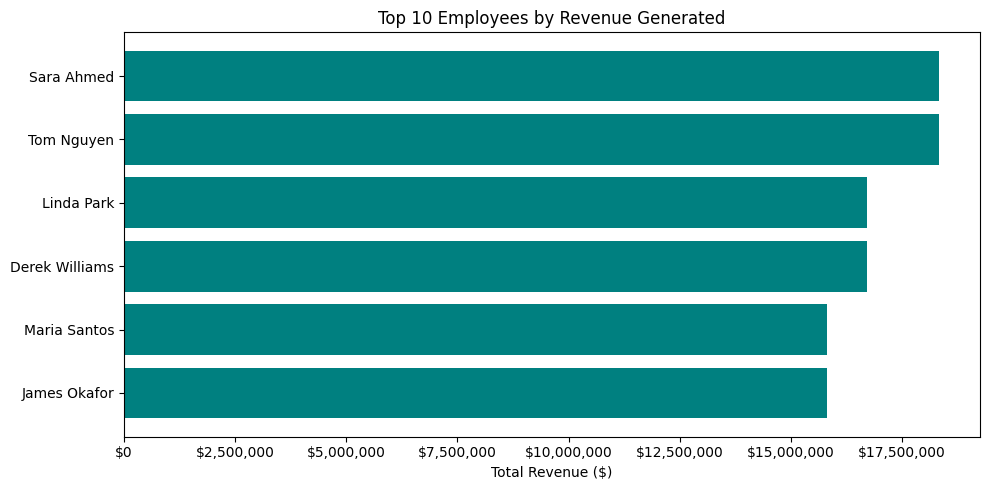

In [54]:
# Chart: top employees by revenue 
top_emp = emp_performance.head(10)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top_emp['employee_name'], top_emp['total_revenue'], color='teal')
ax.set_xlabel('Total Revenue ($)')
ax.set_title('Top 10 Employees by Revenue Generated')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.invert_yaxis()  # highest at the top
plt.tight_layout()
plt.show()

## 9. Payment Method Analysis
How do customers prefer to pay, and does it affect average transaction size?

In [55]:
# Join to payment dimension 
sales_payment = sales.merge(
    payment,
    left_on='dim_payment_method_id',
    right_on='id',
    how='left'
)

payment_summary = (
    sales_payment
    .groupby('method')
    .agg(
        total_revenue    = ('revenue', 'sum'),
        avg_per_item     = ('revenue', 'mean'),
        num_transactions = ('source_transaction_id', 'nunique')
    )
    .sort_values('total_revenue', ascending=False)
    .reset_index()
)

payment_summary['pct_of_revenue'] = (
    payment_summary['total_revenue'] / payment_summary['total_revenue'].sum() * 100
).round(1)

payment_summary

,method,total_revenue,avg_per_item,num_transactions,pct_of_revenue
0,credit,45696882.15,10.032636,1012691,44.9
1,debit,30565374.21,10.029547,677896,30.1
2,cash,15259363.66,10.036176,337919,15.0
3,mobile,10164989.99,10.037890,225289,10.0


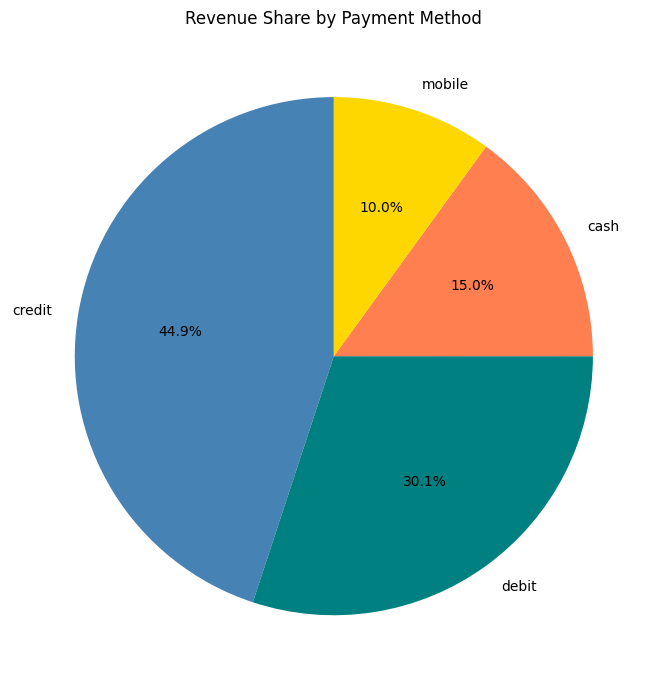

In [56]:
# Pie chart: payment method split 
fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(
    payment_summary['total_revenue'],
    labels=payment_summary['method'],
    autopct='%1.1f%%',
    startangle=90,
    colors=['steelblue','teal','coral','gold']
)
ax.set_title('Revenue Share by Payment Method')
plt.tight_layout()
plt.show()

## 10. Window Functions & Rankings
These patterns mirror SQL window functions, ranking within groups, running totals, period-over-period change.

In [57]:
#  Day-over-day revenue change 
# Shows how much revenue changed compared to the previous day
daily['prev_day_revenue'] = daily['daily_revenue'].shift(1)   # previous day's value
daily['day_over_day_change'] = daily['daily_revenue'] - daily['prev_day_revenue']
daily['day_over_day_pct'] = (daily['daily_revenue'].pct_change() * 100).round(2)

# Best and worst days
print("Top 5 best days:")
print(daily.nlargest(5, 'daily_revenue')[['simulated_day','daily_revenue','day_over_day_pct']])
print("\nTop 5 worst days:")
print(daily.nsmallest(5, 'daily_revenue')[['simulated_day','daily_revenue','day_over_day_pct']])

Top 5 best days:
      simulated_day  daily_revenue  day_over_day_pct
4996           4997       18901.93             40.21
837             838       18644.25             13.80
4915           4916       18607.87             46.32
2429           2430       18449.74             23.23
4839           4840       18434.53             22.11

Top 5 worst days:
      simulated_day  daily_revenue  day_over_day_pct
3065           3066       11590.83            -34.90
619             620       11680.79            -25.27
4546           4547       11856.89            -27.07
5363           5364       11926.30             -7.40
2211           2212       12002.49            -21.13


In [58]:
#  Cumulative revenue over time 
# Running total, shows when the store crossed major milestones
daily['cumulative_revenue'] = daily['daily_revenue'].cumsum()
daily['cumulative_profit']  = daily['daily_profit'].cumsum()

# What day did we cross $10M, $50M, $100M in revenue?
for milestone in [10_000_000, 25_000_000, 50_000_000, 100_000_000]:
    day_hit = daily[daily['cumulative_revenue'] >= milestone]['simulated_day'].min()
    print(f"${milestone/1_000_000:.0f}M milestone reached on day: {day_hit}")

$10M milestone reached on day: 657
$25M milestone reached on day: 1641
$50M milestone reached on day: 3279
$100M milestone reached on day: 6558


In [59]:
#  Rank products within each category by revenue 
# Same as SQL: RANK() OVER (PARTITION BY category ORDER BY revenue DESC)
cat_product_revenue = (
    sales_product
    .groupby(['category', 'product_name'])['revenue']
    .sum()
    .reset_index()
)

cat_product_revenue['rank_in_category'] = (
    cat_product_revenue
    .groupby('category')['revenue']
    .rank(method='dense', ascending=False)
    .astype(int)
)

# Show the top product per category
top_per_category = (
    cat_product_revenue[cat_product_revenue['rank_in_category'] == 1]
    .sort_values('revenue', ascending=False)
)
top_per_category

,category,product_name,revenue,rank_in_category
7,Beverages,Coffee (12oz ground),5165420.26,1
30,Pantry,Olive Oil (16oz),4601648.74,1
17,Frozen,Chicken Nuggets (24oz),4318097.35,1
22,Meat,Bacon (12oz),4034516.16,1
13,Dairy,Greek Yogurt (32oz),3450455.64,1
1,Bakery,Blueberry Muffins (4pk),2585490.17,1
41,Produce,Russet Potatoes (5lb),2289094.92,1


In [60]:
#  Outlier detection on daily revenue 
# IQR method — flag days that are unusually high or low
q1 = daily['daily_revenue'].quantile(0.25)
q3 = daily['daily_revenue'].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = daily[
    (daily['daily_revenue'] < lower_bound) |
    (daily['daily_revenue'] > upper_bound)
]

print(f"Normal revenue range: ${lower_bound:,.2f} — ${upper_bound:,.2f}")
print(f"Outlier days found:   {len(outliers)}")
outliers[['simulated_day','daily_revenue']].head(10)

Normal revenue range: $12,585.78 — $17,916.58
Outlier days found:   43


,simulated_day,daily_revenue
10,11,18043.64
619,620,11680.79
628,629,12455.80
758,759,12481.77
804,805,18155.01
813,814,18310.69
837,838,18644.25
961,962,18085.11
1321,1322,18054.27
1453,1454,18199.24


## 11. Correlation Analysis
Do any variables move together? Useful for spotting relationships in the data.

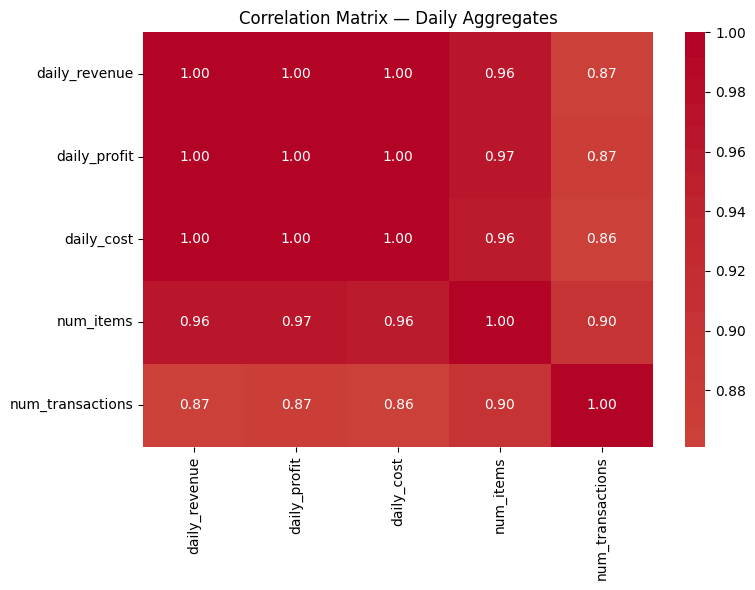

In [61]:
# Correlation matrix on daily aggregates 
daily_corr = daily[['daily_revenue','daily_profit','daily_cost','num_items','num_transactions']].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    daily_corr,
    annot=True,       # show the number in each cell
    fmt='.2f',        # 2 decimal places
    cmap='coolwarm',  # red = strong positive, blue = strong negative
    center=0,
    ax=ax
)
ax.set_title('Correlation Matrix — Daily Aggregates')
plt.tight_layout()
plt.show()

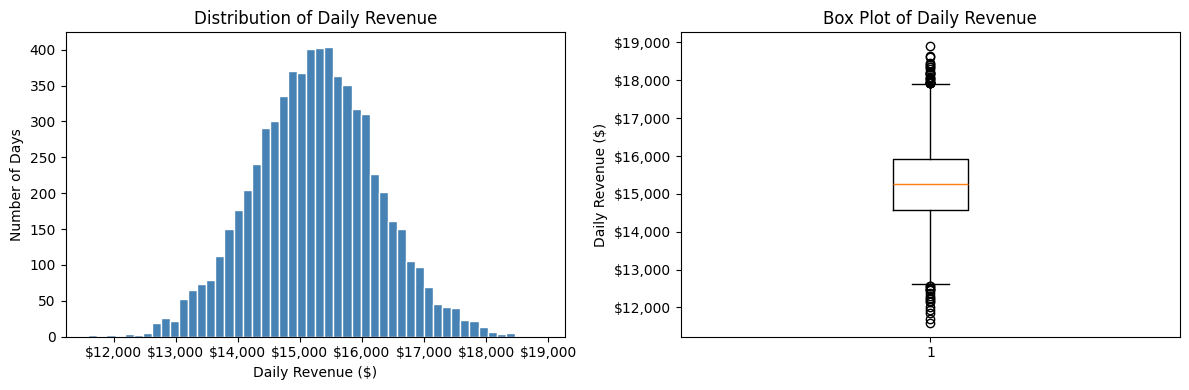

In [62]:
#  Distribution of daily revenue 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(daily['daily_revenue'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Daily Revenue')
axes[0].set_xlabel('Daily Revenue ($)')
axes[0].set_ylabel('Number of Days')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Box plot — shows median, IQR, and outliers
axes[1].boxplot(daily['daily_revenue'], vert=True)
axes[1].set_title('Box Plot of Daily Revenue')
axes[1].set_ylabel('Daily Revenue ($)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()